# Лабораторная работа 6
Выделить фрукты на изображении

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image = cv.imread('oranges.jpg')
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

gs = plt.GridSpec(1, 2)

def region_growingHSV(image, seed, threshold):
    # Create an empty binary mask to store the segmented region
    region_mask = np.zeros(image.shape[0:2], dtype=np.uint8)

    # Define the connectivity (4-connectivity in this case)
    connectivity = [(1, 0), (-1, 0), (0, 1), (0, -1)]
    # Create a queue to store the pixels to be processed
    queue = []

    for i in seed:
        # Get the seed coordinates
        seed_x, seed_y = i
        queue.append((seed_x, seed_y))

        # Perform region growing
        while len(queue) > 0:
            x, y = queue.pop(0)

            # Check if the pixel is within the image boundaries
            if x < 0 or x >= image.shape[0] or y < 0 or y >= image.shape[1]:
                continue

            # Check if the pixel has already been visited
            if region_mask[x, y] != 0:
                continue

            # Calculate the similarity measure
            similarity = sum(abs(image[x, y, :] - image[seed_x, seed_y, :]))/3

            # Check if the pixel is similar to the seed pixel
            if similarity < threshold:
                region_mask[x, y] = 255  # Add the pixel to the region
                # Add the neighbors to the queue for further processing
                for dx, dy in connectivity:
                    queue.append((x + dx, y + dy))

    return region_mask

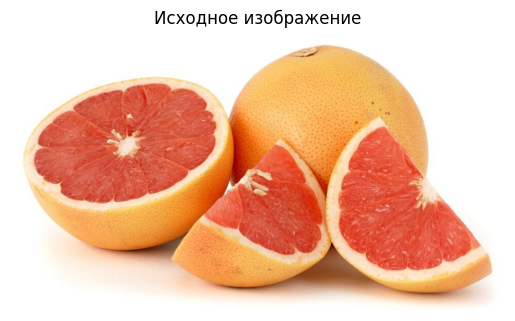

In [2]:
plt.figure()
plt.title("Исходное изображение")
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

## Преобразование в HSV

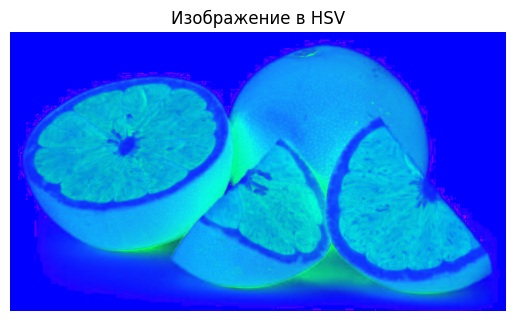

In [3]:
image_hsv = cv.cvtColor(image_rgb, cv.COLOR_RGB2HSV)

plt.figure()
plt.title("Изображение в HSV")
plt.imshow(image_hsv)
plt.axis("off")
plt.show()

### Создание и применение маски по апельсинам методом разрастания областей (Начальные точки подобраны просто друг за дружкой, чтоб закрыть все дыры)

C:\Users\vladk\AppData\Local\Temp\ipykernel_30108\387155397.py:37: RuntimeWarning: overflow encountered in scalar add
  similarity = sum(abs(image[x, y, :] - image[seed_x, seed_y, :]))/3


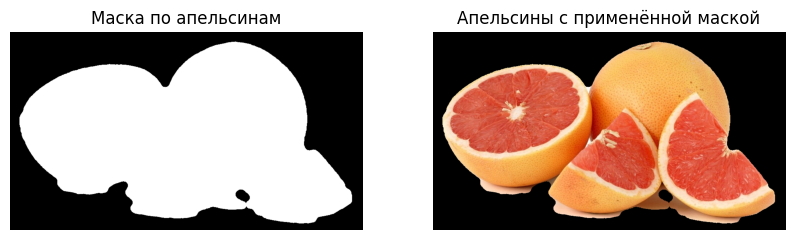

In [15]:
seeds = [
    (160, 200),
    (140, 400),
    (360, 280),
    (265, 35),
    (235, 630),
    (330, 360),
    (200, 470),
    (350, 325),
    (390, 300),
    (270, 615),
    (280, 400)
]
threshold = 40
mask = region_growingHSV(image_hsv, seeds, threshold)

kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (23, 23))
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)

image_with_mask = cv.bitwise_and(image_rgb, image_rgb, mask=mask)

plt.figure(figsize=(10, 6))
plt.subplot(gs[0])
plt.title("Маска по апельсинам")
plt.imshow(mask, cmap="gray")
plt.axis("off")

plt.subplot(gs[1])
plt.title("Апельсины с применённой маской")
plt.imshow(image_with_mask)
plt.axis("off")
plt.show()

### Создание маски для удаления тени

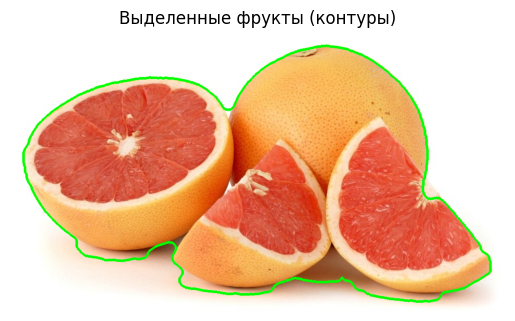

In [16]:
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

output = image_rgb.copy()
for cnt in contours:
    cv.drawContours(output, [cnt], -1, (0, 255, 0), 3)

plt.figure()
plt.title("Выделенные фрукты (контуры)")
plt.imshow(output)
plt.axis("off")
plt.show()